# Multilayer Zigzag Persistent Homology:
## Jason LaRuez, Audun Myers, Brendan Rooney
This notebook contains the code for generating many of the Chapter 1 (periodic ring example) figures from the dissertation "Topological Tools for the Analysis of Complex Networks and Higher-Order Networks". We apply multilayer zigzag persistence to an illustrative ring example where temporal-topological dynamics are present.

Disclaimer: much of code used for the final plots was created using generative AI

In [1]:
# Mounting to google drive. Forced remount allows you to access newly uploaded/updated files and
# folders in the googe drive. If files are stored locally or elsewhere, can comment out
from google.colab import drive
drive.mount('/content/drive', force_remount = True)

import networkx as nx # Network structures
import numpy as np # Numpy arrays and operations
import random # Random sampling for network models
from itertools import combinations, product # For getting different simplices and all combinations of lists
import seaborn as sns # Displaying heatmaps

import matplotlib.pyplot as plt # Plotting
import matplotlib.animation as animation # Animating plots
import time # Timing simulations
from tqdm.notebook import trange, tqdm # Allows for real-time progress bar of simulations

import gc # Memory management
import pickle # Takes environment variables and saves them as is
import gzip # Allows for compression of saved files
from joblib import Parallel, delayed # Parallelization functions
import multiprocessing # Get number of cpu cores
import os # Iterating over directories for files
import math

# Installing packages not included in base google colab environment
!pip install dionysus==2.0.10 # Last version that is compatible with google colab
import dionysus as d # C++ package with python bindings for persistent homology

# Custom script for this notebook
from Multilayer_ZZPH import * # Multilayer Zigzag Persistent Homology

# For use on google colab
##import sys
##sys.path.append('/content/drive/MyDrive/Colab Notebooks')
##from Multilayer_ZZPH import * # Multilayer Zigzag Persistent Homology

Mounted at /content/drive


We consider a simple model exhibiting periodic topological properties as an illustrative example for MLZZPH. We consider an empty graph with $N$ nodes, which we can imagine arranged in a circle so that nodes $v_0$ and $v_1$ are adjacent, as are $v_1$ and $v_2$, and so on, up to $v_{N-1}$ and $v_0$. At each timestep $t=0,1,2,...$, edges are randomly added between neighboring vertices on the ring, independently with probability $p(t)$. These edges are then removed at the beginning of the next time step, making the connections instantaneous rather than persisting across timesteps. To make this example temporally interesting, we require that the probability of including ring edges follow a sinusoid $p(t) = \frac{p_{max}}{2}\sin{\frac{2\pi t}{T}} + \frac{p_{max}}{2}$ where $p_{max}$ is the peak of the sinusoid and $T$ is the period length of the sinusoid. Thus, at any given time step, the full ring forms with probability $p(t)^N$, which is generally improbable unless $p_{max}$ is close to 1 or $N$ is small. However, if we aggregate the edges across multiple time windows, the true ring structure appears

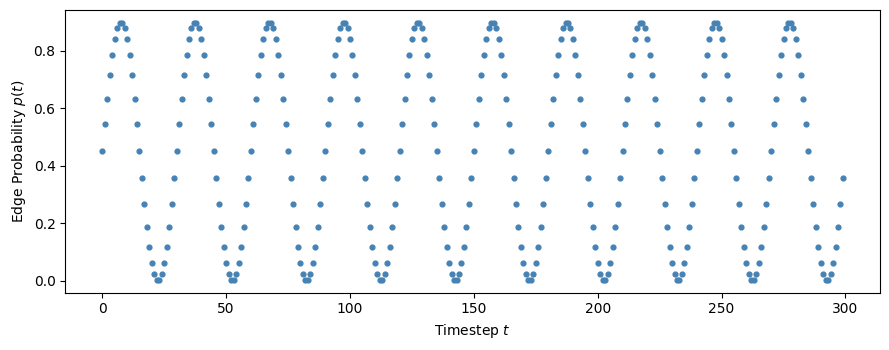

In [2]:
period = 30
max_p_WS = 0.9
steps = np.arange(period * 10)
p = 0.5 * max_p_WS * np.sin(2 * np.pi * steps / period) + 0.5 * max_p_WS

fig, ax = plt.subplots(figsize=(9, 3.6))
ax.scatter(steps, p, s=12, color='steelblue')
ax.set_xlabel(r'Timestep $t$')
ax.set_ylabel(r'Edge Probability $p(t)$')

plt.tight_layout()
plt.show()

  0%|          | 0/3 [00:00<?, ?it/s]

  0%|          | 0/40 [00:00<?, ?it/s]

Calculating 1-distance for Period 20:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/60 [00:00<?, ?it/s]

Calculating 1-distance for Period 30:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 40:   0%|          | 0/8 [00:00<?, ?it/s]

/content/drive/MyDrive/Colab Notebooks/Multilayer_ZZPH.py:316: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])


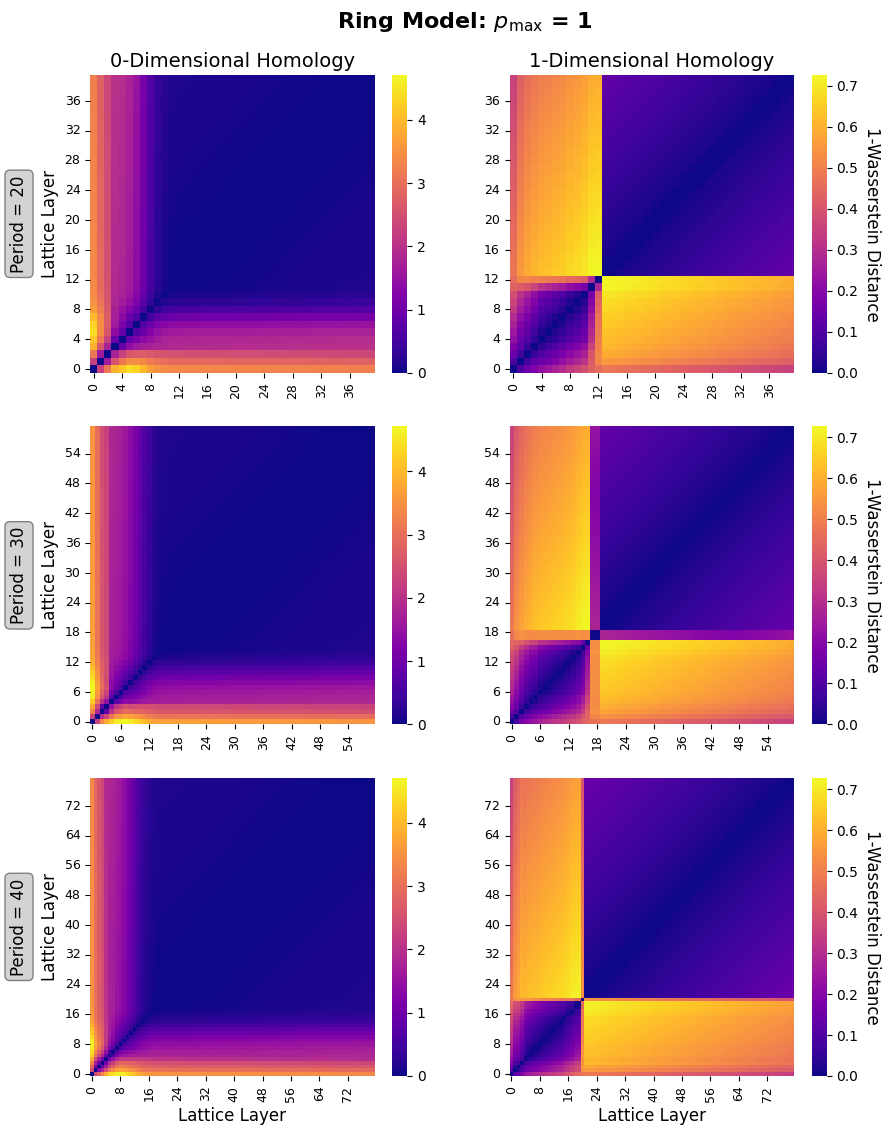

In [3]:
N = 50; p_ER = 0; max_p_WS = 1; k_WS = 2; periods = [20,30,40]; #steps = 100
D0 = {period: dict() for period in periods}; D1 = {period: dict() for period in periods}; DGMs = {}
width = 1;

for period in tqdm(periods):
    length = 5 * period
    Edges = PeriodicRing(N, p_ER, max_p_WS, k_WS, period, length)
    DGMs[period] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[period].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, period, DGMs, '1')
    D0[period]['1'] = d0
    D1[period]['1'] = d1

# Figure 1.7: periods 20, 30, 40 w/ p_max = 1
plot_period_group_publication([20, 30, 40], D0, D1, max_p_WS, figsize=(10, 13), name = '1.7.png')

Figure 1.7: Heatmaps of 1-Wasserstein distance between persistence diagrams for layers 0 to $2T$ for $T\in\{20,30,40\}$ and $p_{max}=1$. In the left column, corresponding to the 0-homology persistence diagrams, we see a gradual change in the diagrams for the lower layers as short-lived components slowely merge together, followed by no change. This corresponds to the aggregation of more and more edges as the window size increases, until a single component persists. In the right column, corresponding to the 1-homology persistence diagrams, we see that the lower layers are all very similar to each other, and the higher layers are very similar to each other, with an abrupt transition around layer $\frac{T}{2}$ corresponding to the identification of the single persistent ring.

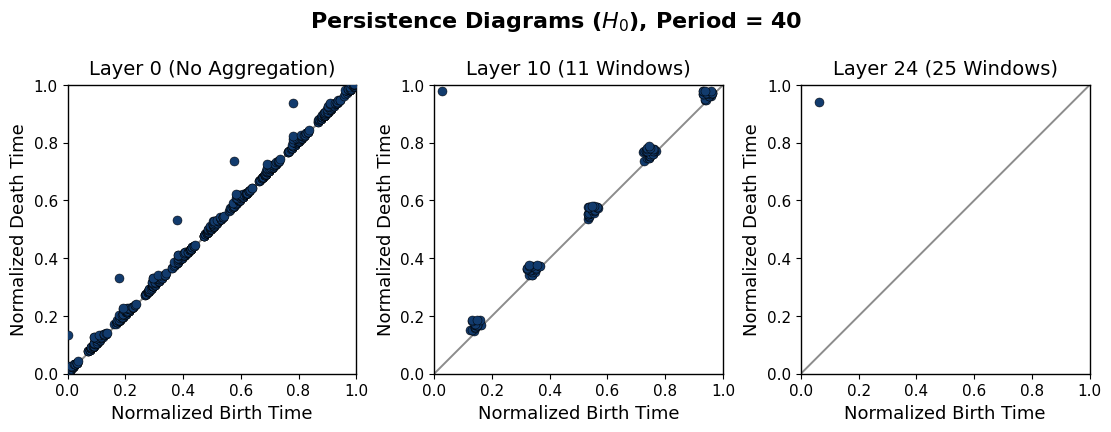

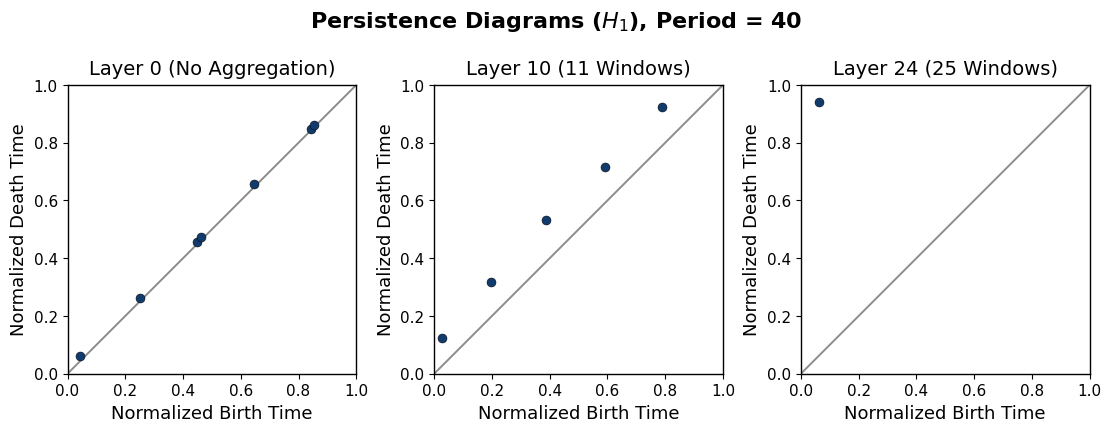

In [4]:
# Example usage for your four diagrams
layer1 = 0
layer2 = 10
layer3 = 24
period = 40

# ---- H0 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][0], ax=ax[0], title=f"Layer {layer1} (No Aggregation)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][0], ax=ax[1], title=f"Layer {layer2} ({layer2+1} Windows)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][0], ax=ax[2], title=f"Layer {layer3} ({layer3+1} Windows)"
)

fig.suptitle(f"Persistence Diagrams ($H_0$), Period = {period}", fontsize=16, fontweight="bold", y = 0.9)
plt.savefig('1.8.1.png')
plt.show()


# ---- H1 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][1], ax=ax[0], title=f"Layer {layer1} (No Aggregation)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][1], ax=ax[1], title=f"Layer {layer2} ({layer2+1} Windows)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][1], ax=ax[2], title=f"Layer {layer3} ({layer3+1} Windows)"
)

fig.suptitle(f"Persistence Diagrams ($H_1$), Period = {period}", fontsize=16, fontweight="bold", y = 0.9)
plt.savefig('1.8.2.png')
plt.show()

Figure 1.8: Persistence diagrams of the 0-homology ($H_0$, top row) and 1-homology ($H_1$, bottom row) for layers 0 (left column), 10 (middle column), and 24 (right column) over five periods of $T=40$ timesteps with $p_{max}=1$. These diagrams illustrate the transitions seen in the heatmaps of Figure 1.7, where many short-lived components ($H_0$) gradually merge together until a single component remains, and where short-lived tunnels ($H_1$) initially exist for each period simulated but abruptly merge together into a single persistent ring.

In [5]:
N = 50; p_ER = 0; max_P = [0.25, 0.5, 0.75, 0.8, 1]; k_WS = 2; period = 40;
D0 = {p: dict() for p in max_P}; D1 = {p: dict() for p in max_P}; DGMs = {}
width = 1;

for p in tqdm(max_P):
    length = 5 * period
    Edges = PeriodicRing(N, p_ER, p, k_WS, period, length)
    DGMs[p] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[p].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, p, DGMs, '1')
    D0[p]['1'] = d0
    D1[p]['1'] = d1

  0%|          | 0/5 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.25:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.5:   0%|          | 0/8 [00:00<?, ?it/s]

...

Calculating 1-distance for Period 0.75:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.8:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 1:   0%|          | 0/8 [00:00<?, ?it/s]

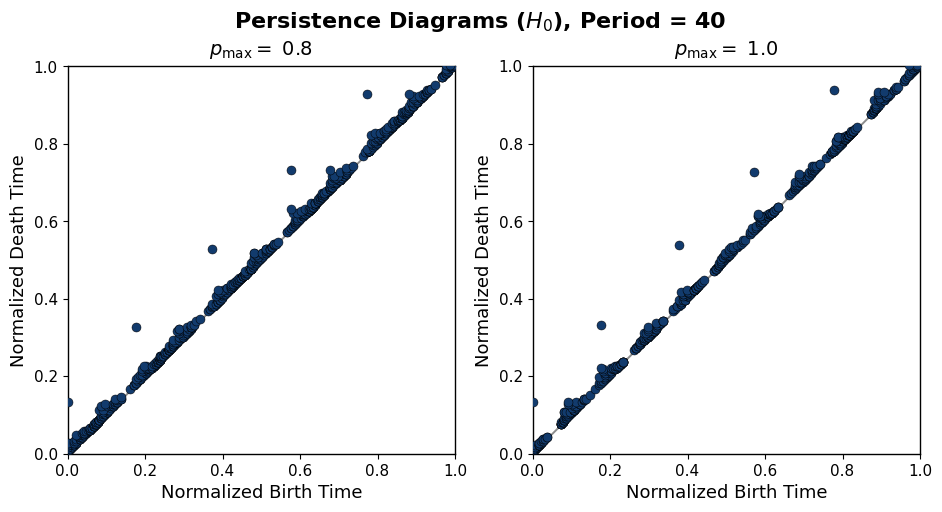

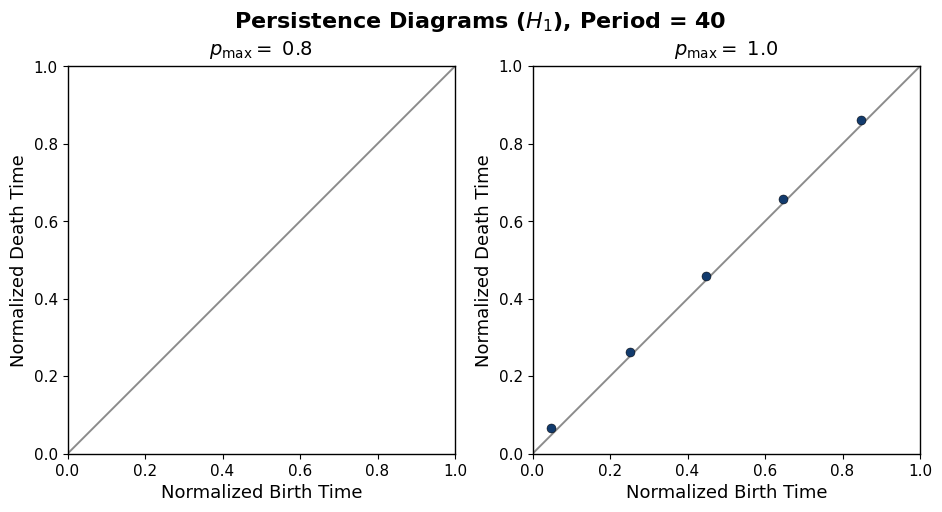

In [6]:
# Example usage for your four diagrams
layer1 = 0
layer2 = 0
p_1 = 0.8
p_2 = 1.0

# ---- H0 figure ----
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))#, constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[p_1][layer1][0], ax=ax[0], title=f"$p_{{\\max}} = $ {p_1}"
)

plot_persistence_diagram_publication(
    DGMs[p_2][layer2][0], ax=ax[1], title=f"$p_{{\\max}} = $ {p_2}"
)

fig.suptitle(f"Persistence Diagrams ($H_0$), Period = {period}", fontsize=16, fontweight="bold", y = 0.95)
plt.savefig('1.4.1.png')
plt.show()


# ---- H1 figure ----
fig, ax = plt.subplots(1, 2, figsize=(11, 5.5))#, constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[p_1][layer1][1] if len(DGMs[p_1][layer2]) > 1 else d.Diagram(), ax=ax[0], title=f"$p_{{\\max}} = $ {p_1}"
)

plot_persistence_diagram_publication(
    DGMs[p_2][layer2][1] if len(DGMs[p_2][layer2]) > 1 else d.Diagram(), ax=ax[1], title=f"$p_{{\\max}} = $ {p_2}"
)

fig.suptitle(f"Persistence Diagrams ($H_1$), Period = {period}", fontsize=16, fontweight="bold", y = 0.95)
plt.savefig('1.4.2.png')
plt.show()

Figure 1.4: For a graph with $N=50$ nodes, period length $T=40$ timesteps, $p_{max}\in\{0.8,1.0\}$ we simulate the ring for $5\cdot T$ many steps, construct the clique complex at each step, then compute ZZPH and plot the resultant persistence diagrams. Recall that each point is a pair of "birth" and "death" times corresponding to the time when a homology class appears and disappears, respectively. Points that are close to the main diagonal are short-lived features that are generally treated as unimportant, or noise, while points further from the diagonal correspond to persistent topological features. In the 0-homology persistence diagrams, note that even without aggregating time windows, ZZPH identifies a periodically forming and disintegrating component, as indicated by the five off-diagonal points corresponding to the five simulated periods. However, the 1-homology persistence does not capture the ring structure at all for $p_{max}=0.8$, and only as a short-lived noisy feature when $p_{max}=1.0$.

/content/drive/MyDrive/Colab Notebooks/Multilayer_ZZPH.py:489: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])


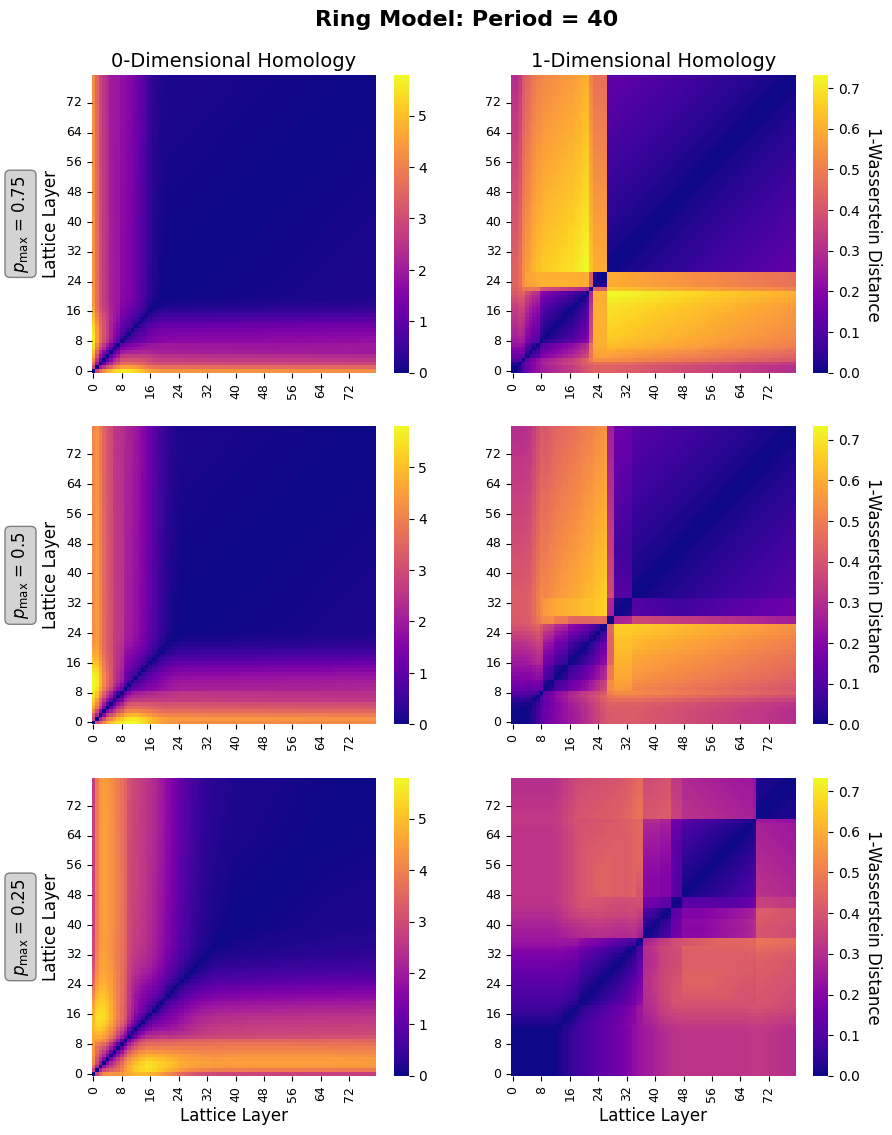

In [7]:
# Figure 1: pmax = 0.75, 0.50, 0.25
plot_period_group_publication_pmax([0.75,0.5,0.25], D0, D1, 40, figsize=(10, 13), name = '1.9.png')

Figure 1.9: Heatmaps of 1-Wasserstein distance between persistence diagrams for layers $0$ to $2T$ for $T=40$ and $p_{max}\in\{0.25,0.50,0.75\}$. In the left column we see that decreasing $p_{max}$ causes the accumulation of components to occur over a larger range of layers, requiring higher layers for the single persistent component to be identified. In the right column we see a similar trend where the abrupt transition from multiple transient rings to a single persistent ring is delayed to higher layers as $p_{max}$ decreases.

  0%|          | 0/2 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.001:   0%|          | 0/8 [00:00<?, ?it/s]

  0%|          | 0/80 [00:00<?, ?it/s]

Calculating 1-distance for Period 0.005:   0%|          | 0/8 [00:00<?, ?it/s]

/content/drive/MyDrive/Colab Notebooks/Multilayer_ZZPH.py:592: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0.10, 0.04, 0.98, 0.91])


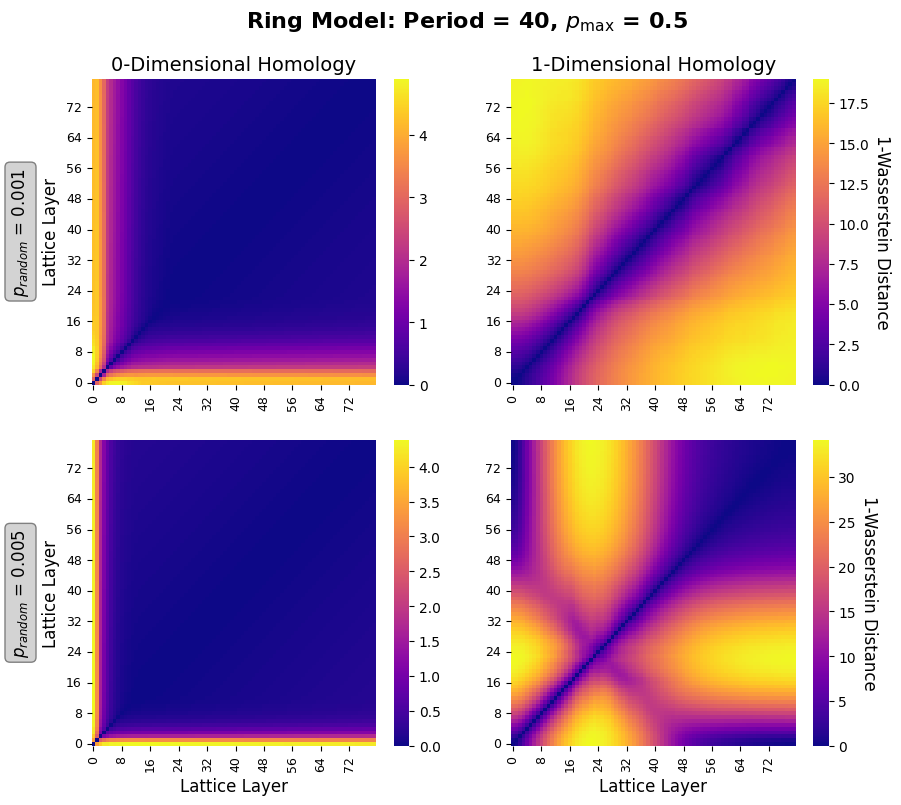

In [8]:
N = 50; p_ER = [0.001,0.005]; max_P = 0.5; k_WS = 2; period = 40;
D0 = {p: dict() for p in p_ER}; D1 = {p: dict() for p in p_ER}; DGMs = {}
width = 1;

for p in tqdm(p_ER):
    length = 5 * period
    Edges = PeriodicRing(N, p, max_P, k_WS, period, length)
    DGMs[p] = []
    layers = range(2 * period)
    for layer in tqdm(layers):
        W = Windowing(width, layer, Edges)
        dgms = ZZPH(W, width, layer)
        DGMs[p].append(dgms)

    # Calculate 1-Wasserstein Distance
    d0, d1 = compute_distance_matrices(layers, p, DGMs, '1')
    D0[p]['1'] = d0
    D1[p]['1'] = d1

plot_period_group_publication_prandom([0.001,0.005], D0, D1, 40, figsize=(10, 13*2/3), name = '1.10.png')

Figure 1.10: Heatmaps of 1-Wasserstein distance between persistence diagrams for layers $0$ to $2T$ for $T=40$ with $p_{max}=0.50$ and $p_{random}\in\{0.001,0.005\}$. In the left column we see that the inclusion of random edges causes the aggregation of a single component to occur at lower layers. By introducing a probability $p_{random}$ of including non-ring edges, we see that the abrupt 1-homology transitions become distorted.

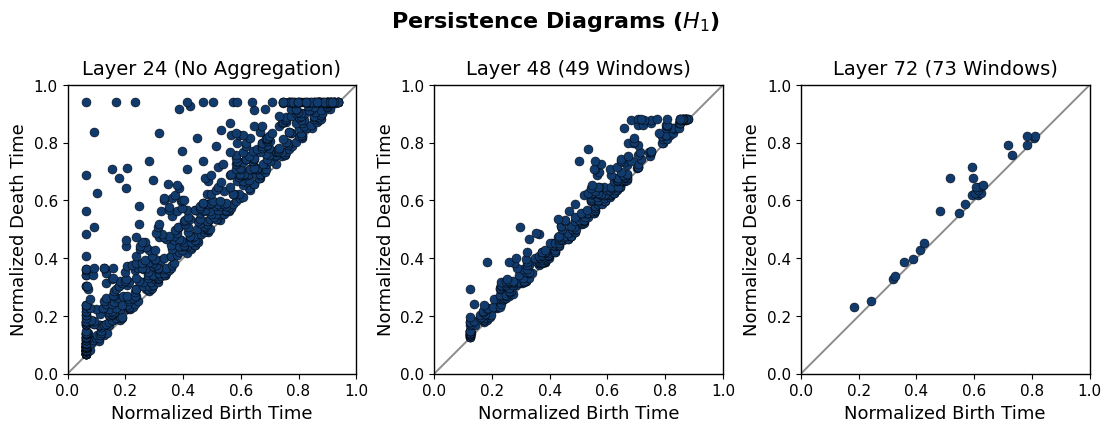

In [9]:
# Example usage for your four diagrams
layer1 = 24
layer2 = 48
layer3 = 72
period = 0.005

# ---- H1 figure ----
fig, ax = plt.subplots(1, 3, figsize=(11, 5.5), constrained_layout=True)

plot_persistence_diagram_publication(
    DGMs[period][layer1][1], ax=ax[0], title=f"Layer {layer1} (No Aggregation)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer2][1], ax=ax[1], title=f"Layer {layer2} ({layer2+1} Windows)"
)

plot_persistence_diagram_publication(
    DGMs[period][layer3][1], ax=ax[2], title=f"Layer {layer3} ({layer3+1} Windows)"
)

fig.suptitle(f"Persistence Diagrams ($H_1$)", fontsize=16, fontweight="bold", y = 0.9)
plt.savefig('1.11.png')
plt.show()

Figure 1.11: Persistence diagrams of the 1-homology for layers over five periods of $T=40$ timesteps with $p_{max}=0.5$ and $p_{random}=0.005$, illustrating the smooth transitions observed in Figure 1.10. The introduction of noisy edges initially causes the formation of many short-lived tunnels (1-holes), followed by the formation of cliques that fill the numerous tunnels, hiding the true ring structure.